# COMPARANDO MODELOS DE REGRESIÓN PARA DATASET INSURANCE
## DATASET [kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 25.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1

insurance.csv


In [4]:
PATH_CSV = path + "/insurance.csv"

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [6]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [7]:
df = pd.read_csv(PATH_CSV)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


 # PASO 3 : EDA

## VERIFICAMOS SI HAY VALORES NULOS

In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [10]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['sex', 'smoker', 'region'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [11]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
sex
male      676
female    662
Name: count, dtype: int64
**************************************************
smoker
no     1064
yes     274
Name: count, dtype: int64
**************************************************
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## 4.3 DIVIDO LAS VARIABLES POR TIOP DE CODIFICACIÓN(LABEL Y ONE HOT ENCODING)

In [12]:
ordinal_cols = ['sex','smoker']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(f'ordinal cols : {ordinal_cols}')
print(f'onehot cols : {onehot_cols}')

ordinal cols : ['sex', 'smoker']
onehot cols : ['region']


## 4.4 CODIFICAMOS USANDO LOS MODULOS COMPOSE Y PREPROCESSING DE SKLEARN

In [13]:
import sklearn.compose
import sklearn.preprocessing

In [14]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['sex', 'smoker']),
                                ('onehotencoder', OneHotEncoder(), ['region'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [15]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__sex,ordinalencoder__smoker,onehotencoder__region_northeast,onehotencoder__region_northwest,onehotencoder__region_southeast,onehotencoder__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [16]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age,bmi,children,charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [17]:
data_transformed_df.dtypes

,0
sex,float64
smoker,float64
region_northeast,float64
region_northwest,float64
region_southeast,float64
region_southwest,float64
age,float64
bmi,float64
children,float64
charges,float64


# 5 - CORRELACIONES

In [18]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['charges']
corr_charges.sort_values(ascending=False)

,charges
charges,1.000000
smoker,0.787251
age,0.299008
bmi,0.198341
region_southeast,0.073982
children,0.067998
sex,0.057292
region_northeast,0.006349
region_northwest,-0.039905
region_southwest,-0.043210


<Axes: >

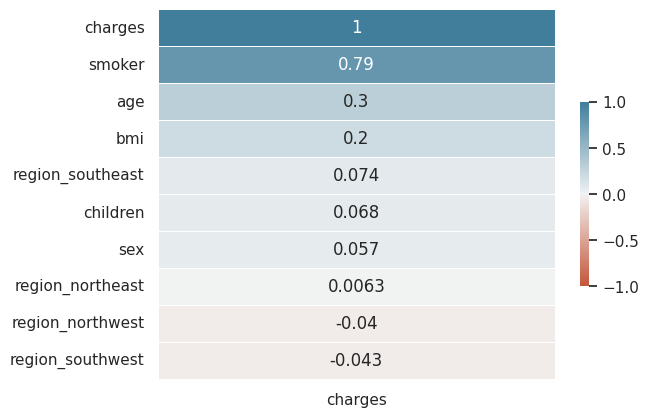

In [19]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [20]:
cols = corr_charges.index.tolist()
cols.remove('charges')
cols

['sex',
 'smoker',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'age',
 'bmi',
 'children']

# 6 - ENTRENAMIENTO DEL MODELO

In [21]:
#X_cols = ['smoker','age','bmi']
X_cols = cols
y_col = ['charges']

In [22]:
X = data_transformed_df[X_cols].values
y = data_transformed_df[y_col].values.reshape(-1,1)

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [24]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## 2 - ESCALAMIENTO DE DATOS

In [25]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='linear'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [27]:
results = {}
for name,model in models.items():
    model.fit(X_train_scaled,y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)

    r2 = r2_score(y_test_scaled,y_pred_scaled)
    mse = mean_squared_error(y_test_scaled,y_pred_scaled)
    mae = mean_absolute_error(y_test_scaled,y_pred_scaled)
    results[name] = {"R2":r2,"MSE":mse,"MAE":mae}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [28]:
results_df = pd.DataFrame(results).T
results_df

,R2,MSE,MAE
Linear Regression,0.783799,0.263411,0.358763
Lasso,0.739626,0.317230,0.395099
Ridge,0.783717,0.263511,0.358927
KNN Regressor,0.819927,0.219393,0.289277
SVR,0.749942,0.304661,0.294742
Random Forest Regressor,0.848658,0.184388,0.233647


# BUSCAMOS EL MEJOR MODELO

In [29]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.8487)
Best model based on MSE: Random Forest Regressor (MSE: 0.18)


# GRAFICAMOS METRICAS DE LOS MODELOS

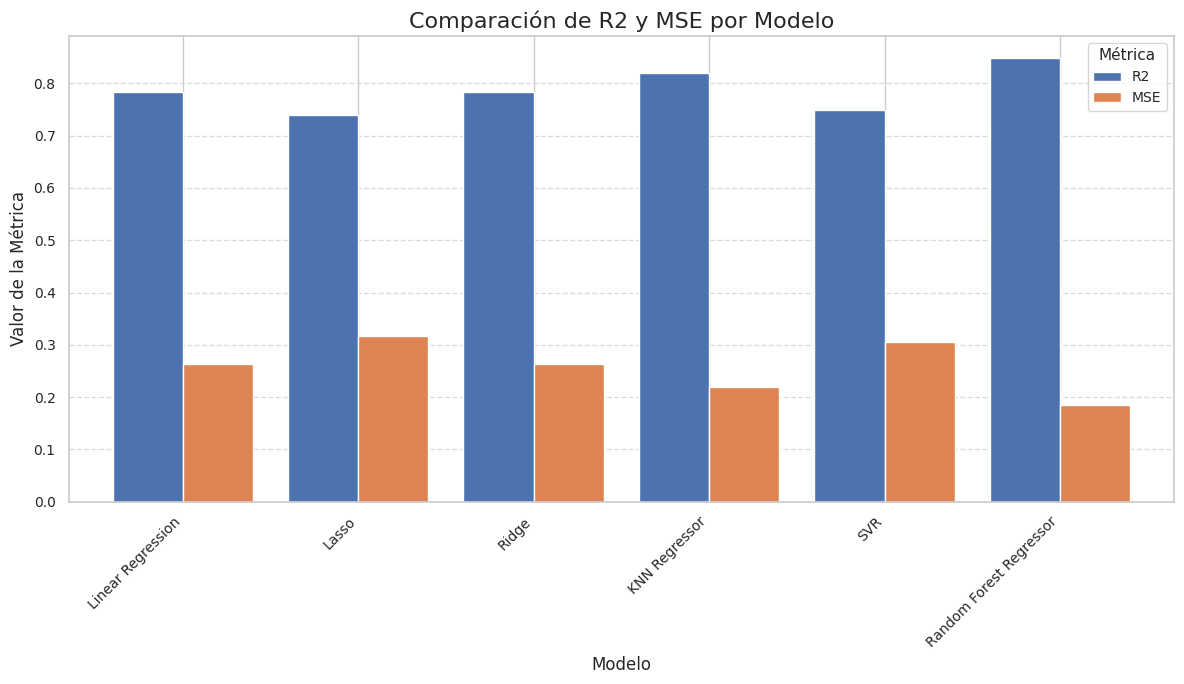

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()